In [1]:
import pandas as pd
import numpy as np

## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv("../data/external/Ponds1.csv", low_memory=False)
df_raw.columns = [c.strip() for c in df_raw.columns]
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 74796 entries, 0 to 74795
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   station          74796 non-null  str    
 1   Date             74796 non-null  str    
 2   Time             74745 non-null  str    
 3   NITRATE(PPM)     74794 non-null  str    
 4   PH               74795 non-null  str    
 5   AMMONIA(mg/l)    74796 non-null  float64
 6   TEMP             74790 non-null  float64
 7   DO               74790 non-null  str    
 8   TURBIDITY        74796 non-null  float64
 9   MANGANESE(mg/l)  74775 non-null  str    
dtypes: float64(3), str(7)
memory usage: 5.7 MB


In [3]:
df_raw.head()

,station,Date,Time,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l)
0,station1,01-02-2022,08:00:00,18.3,5.7,0.010,23.20,11.6,31.7,0.71
1,station1,01-02-2022,08:20:00,3.6,5.1,0.094,23.41,10.5,18.8,0.62
2,station1,01-02-2022,08:40:00,13.1,5.5,0.060,23.63,10.3,23.2,0.73
3,station1,01-02-2022,09:00:00,18.1,5.2,0.018,23.64,9.4,26.7,0.64
4,station1,01-02-2022,09:20:00,10.8,5.2,0.038,23.81,8.8,19.5,0.68


## 2. Type Fixing

Sensor columns loaded as `object` due to `#VALUE!` errors in source file.  
`errors="coerce"` converts bad cells to `NaN` — handled in the next step.

In [4]:
sensor_cols = ["DO","PH","AMMONIA(mg/l)","TEMP","NITRATE(PPM)","TURBIDITY","MANGANESE(mg/l)"]

df_raw["station"] = df_raw["station"].str.lower().str.strip()

for col in sensor_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

df_raw["datetime"] = pd.to_datetime(
    df_raw["Date"] + " " + df_raw["Time"], dayfirst=True, errors="coerce"
)

df_raw.dtypes

station                       str
Date                          str
Time                          str
NITRATE(PPM)              float64
PH                        float64
AMMONIA(mg/l)             float64
TEMP                      float64
DO                        float64
TURBIDITY                 float64
MANGANESE(mg/l)           float64
datetime           datetime64[us]
dtype: object

## 3. Filter to Station 2

Station 2 houses **Catla** (*Catla catla*) — the closest proxy to Nile Tilapia  
in feeding behaviour, environmental tolerances, and farming practice.

In [5]:
df = df_raw[df_raw["station"] == "station2"].copy()
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

Rows: 25,498  |  Columns: 11


## 4. Missing Values

**Decision: drop rows with any NaN in sensor columns or datetime.**  
Imputing sensor readings risks introducing fake water quality events.  
Row loss is < 0.2% of the dataset — negligible.

In [6]:
missing = df[sensor_cols + ["datetime"]].isna().sum()
print(missing[missing > 0])

DO                  6
PH                  1
NITRATE(PPM)        2
MANGANESE(mg/l)    21
datetime           17
dtype: int64


In [7]:
df.dropna(subset=sensor_cols + ["datetime"], inplace=True)

# Drop confirmed sensor hardware faults
# TEMP == 0 and DO == 0 are physically impossible — sensor disconnection, not real readings
df = df[(df["TEMP"] > 5) & (df["DO"] != 0)].reset_index(drop=True)

print(f"Clean rows: {df.shape[0]:,}")

Clean rows: 25,429


## 5. Label Generation

### Why 3 Classes?

Published literature documents a genuine middle state for every parameter:

| Parameter | Prime — feed fully | Reduce — feed less | Halt — stop feeding | Source |
|---|---|---|---|---|
| DO | ≥ 5.0 mg/L | 3.0 – 5.0 mg/L | < 3.0 mg/L | Boyd (1990); Tran-Duy et al. (2008) |
| pH | 6.5 – 8.5 | 6.0–6.5 or 8.5–9.0 | < 6.0 or > 9.0 | Boyd (1990); Pillay (2004) |
| Ammonia | < 0.10 mg/L | 0.10 – 0.25 mg/L | > 0.25 mg/L | Hargreaves & Tucker (2004); Boyd (1990) |
| Temperature | 25 – 30 °C | 22–25 or 30–33 °C | < 15 °C or > 33 °C | Pillay (2004); Das et al. (2012) |
| Nitrate | < 50 ppm | 50 – 100 ppm | > 100 ppm | Boyd (1990); FAO (2005) |
| Turbidity | < 30 NTU | 30 – 40 NTU | > 40 NTU | Boyd (1990); FAO earthen pond guidelines |

---

### Why Noise Boundaries?

None of the published papers give hard-line thresholds - they describe zones and
gradients. **Sprague (1990)** formalises this as the **No Observable Effect Level
(NOEL)**: biological responses near a threshold are continuous gradients. A fish at pH 6.49 and a fish at pH 6.51 behave almost identically.

Noise band width equals typical test kit measurement precision for each parameter:

| Parameter | Noise (±) | Precision basis |
|---|---|---|
| DO | ± 0.3 mg/L | Digital DO pen meter |
| pH | ± 0.2 units | Colorimetric kit |
| Ammonia | ± 0.02 mg/L | Colorimetric kit |
| Temperature | ± 0.5 °C | Pond thermometer |
| Nitrate | ± 5 ppm | Test strip |
| Turbidity | ± 3 NTU | Secchi disk |

---

### Why Deterministic Scoring?

**Zadeh (1965)** *Fuzzy Sets*, Information and Control - demonstrates that category
membership near a boundary should be a continuous value. A reading
at pH 6.45 (midpoint of its noise band) has partial membership in both Prime and
Reduce - represented by a score of 0.25, which flows into the weighted total.

**Sokolova & Lapalme (2009)** - state that reproducible label assignment
(same input -> same output always) is a requirement for valid machine learning
evaluation. Randomness violates this.

The score function uses **linear interpolation** across each noise band:

```plain
fraction = (distance from band entry) / (total band width)
score    = entry_score + fraction × (exit_score - entry_score)
```

Reading left to right on the number line, the entry score is always the zone you are
leaving and the exit score is always the zone you are entering.

---

### Why Weights?

**Wedemeyer (1996)** ranks stressors by speed of feeding suppression:

| Parameter | Weight | Speed of effect | Source |
|---|---|---|---|
| DO | 0.35 | Minutes | Wedemeyer (1996); Boyd (1990) |
| Ammonia | 0.25 | Hours | Hargreaves & Tucker (2004) |
| Temperature | 0.15 | Hours to a day | Das et al. (2012) |
| pH | 0.15 | Hours to days | Pillay (2004) |
| Nitrate | 0.05 | Days to weeks | FAO (2005) |
| Turbidity | 0.05 | Days to weeks | Boyd (1990) |

Weights sum to 1.0.

---

### The 3-Layer Label Assignment Logic

**Layer 1 — Hard overrides** *(applied first, before any scoring)*

At these published cessation thresholds the fish will not feed regardless of every
other parameter. Running the weighted calculation when the answer is already known
from a single parameter would be pointless — the override fires immediately and
returns Halt.

| Override | Threshold | Source |
|---|---|---|
| DO | < 3.0 mg/L | Boyd (1990): *"feeding ceases entirely below 3 mg/L"* |
| pH low | < 6.0 | Pillay (2004): *"severe stress and feeding cessation"* |
| pH high | > 9.0 | Boyd (1990): alkaline toxicity |
| Ammonia | > 0.25 mg/L | Hargreaves & Tucker (2004): *"complete feeding cessation"* |
| Temp low | < 15 °C | Pillay (2004): tilapia stop feeding below 15–16 °C |
| Temp high | > 33 °C | Das et al. (2012): feeding ceases above 33 °C |

Note on temperature: Das et al. (2012) describe feeding as *"negligible"* not
*"ceased"* at 22 °C. Pillay (2004) gives actual cessation only below 15–16 °C.
Temperature between 15–22 °C is a Reduce state handled by the scoring function —
not a hard override.

**Layer 2 — Tolerance zone** *(Sprague 1990; Wedemeyer 1996)*

Weighted score ≤ 0.05 → Prime Feed. One parameter barely grazing a noise boundary
while everything else is fine produces no observable stress (Wedemeyer 1996 zone of
tolerance). Requiring an exact score of 0.0 for Prime is too strict — real ponds
never achieve perfection simultaneously across all parameters.

**Layer 3 — Weighted score**

- 0.05 < score ≤ 0.35 → Reduce Feed
- score > 0.35 → Halt Feeding

The threshold of 0.35 equals DO weight (0.35) × full halt score (1.0), meaning DO
alone at full halt triggers a Halt label even when every other parameter is perfect.


### Step 1 — Deterministic Scoring With Noise Boundaries

One `score()` function handles all parameters.
Reading the number line left to right:
- entry score = the zone you are leaving
- exit score  = the zone you are entering
- fraction    = how far through the band the reading sits (0.0 to 1.0)
- result      = entry_score + fraction × (exit_score − entry_score)


In [ ]:
def score(v, low_halt, low_reduce, high_reduce, high_halt, noise):
    """
    Score one sensor reading. Returns a continuous value:
      1.0 = pure halt  |  0.5 = pure reduce  |  0.0 = pure prime
    Values between these are smooth linear blends inside noise bands.

    Parameters
    ----------
    v           : the sensor reading
    low_halt    : published lower halt threshold  (None if parameter has no low side)
    low_reduce  : published lower reduce threshold (None if parameter has no low side)
    high_reduce : published upper reduce threshold (None if parameter has no high side)
    high_halt   : published upper halt threshold  (None if parameter has no high side)
    noise       : half-width of transition band at each boundary (test kit precision)
    """

    # ── STEP 1: clear halt zones ─────────────────────────────────
    if low_halt  is not None and v < low_halt  - noise: return 1.0
    if high_halt is not None and v > high_halt + noise: return 1.0

    # ── STEP 2: clear reduce zones ───────────────────────────────
    # Between halt and reduce, but outside the noise band.
    if low_reduce  is not None and v < low_reduce  - noise: return 0.5
    if high_reduce is not None and v > high_reduce + noise: return 0.5

    # ── STEP 3: noise bands — linear interpolation ───────────────
    if low_halt is not None and (low_halt - noise) <= v <= (low_halt + noise):
        fraction = (v - (low_halt - noise)) / (2 * noise)
        return 1.0 + fraction * (0.5 - 1.0)

    if high_halt is not None and (high_halt - noise) <= v <= (high_halt + noise):
        fraction = (v - (high_halt - noise)) / (2 * noise)
        return 0.5 + fraction * (1.0 - 0.5)

    if low_reduce is not None and (low_reduce - noise) <= v <= (low_reduce + noise):
        fraction = (v - (low_reduce - noise)) / (2 * noise)
        return 0.5 + fraction * (0.0 - 0.5)

    if high_reduce is not None and (high_reduce - noise) <= v <= (high_reduce + noise):
        fraction = (v - (high_reduce - noise)) / (2 * noise)
        return 0.0 + fraction * (0.5 - 0.0)

    # ── STEP 4: none of the above matched → clearly prime ────────
    return 0.0


# Parameter config table — one row per parameter
# col | low_halt | low_reduce | high_reduce | high_halt | noise | weight
PARAMS = [
    ("DO",            3.0,  5.0,  None,  None,  0.3,  0.35),  # Boyd 1990; Tran-Duy 2008
    ("PH",            6.0,  6.5,   8.5,   9.0,  0.2,  0.15),  # Boyd 1990; Pillay 2004
    ("AMMONIA(mg/l)", None, None,  0.10,  0.25,  0.02, 0.25),  # Hargreaves & Tucker 2004
    ("TEMP",          None, None,  30.0,  33.0,  0.5,  0.15),  # Das et al. 2012; Pillay 2004
    ("NITRATE(PPM)",  None, None,  50.0, 100.0,  5.0,  0.05),  # Boyd 1990; FAO 2005
    ("TURBIDITY",     None, None,  30.0,  40.0,  3.0,  0.05),  # Boyd 1990; FAO earthen pond
]

for col, lh, lr, hr, hh, noise, w in PARAMS:
    df[f"s_{col}"] = df[col].apply(
        lambda v, a=lh, b=lr, c=hr, d=hh, e=noise: score(v, a, b, c, d, e)
    )


df[["DO","s_DO","PH","s_PH","AMMONIA(mg/l)","s_AMMONIA(mg/l)","TEMP","s_TEMP"]].head(8)

,DO,s_DO,PH,s_PH,AMMONIA(mg/l),s_AMMONIA(mg/l),TEMP,s_TEMP
0,8.21866,0.0,5.656,1.0,0.022088,0.0,22.91168,0.0
1,6.23826,0.0,5.858,0.5,0.071284,0.0,22.77000,0.0
2,6.33728,0.0,5.454,1.0,0.058232,0.0,22.73964,0.0
3,10.00102,0.0,5.353,1.0,0.018072,0.0,22.33484,0.0
4,11.09024,0.0,5.050,1.0,0.060240,0.0,22.14256,0.0
5,6.04022,0.0,5.555,1.0,0.022088,0.0,22.11220,0.0
6,7.12944,0.0,5.555,1.0,0.048192,0.0,22.09196,0.0
7,9.60494,0.0,5.555,1.0,0.052208,0.0,21.84908,0.0


### Step 2 — Weighted Score

Weights from Wedemeyer (1996) speed-of-effect hierarchy. Sum = 1.0.

    station        Date      Time  NITRATE(PPM)     PH  AMMONIA(mg/l)      TEMP        DO  TURBIDITY  MANGANESE(mg/l)            datetime  s_DO  s_PH  s_AMMONIA(mg/l)  s_TEMP  s_NITRATE(PPM)  s_TURBIDITY  weighted_score  feed_label
0  station2  01-02-2022  00:00:00        29.172  5.656       0.022088  22.91168   8.21866    29.9592          0.64480 2022-02-01 00:00:00   0.0   1.0              0.0     0.0             0.0       0.2466         0.16233           2
1  station2  01-02-2022  00:20:00        14.280  5.858       0.071284  22.77000   6.23826    32.8320          0.65472 2022-02-01 00:20:00   0.0   0.5              0.0     0.0             0.0       0.4860         0.09930           2
2  station2  01-02-2022  00:40:00         5.712  5.454       0.058232  22.73964   6.33728    25.6500          0.65472 2022-02-01 00:40:00   0.0   1.0              0.0     0.0             0.0       0.0000         0.15000           2
3  station2  01-02-2022  01:00:00        21.114  5.353       0.018072  2

<Axes: >

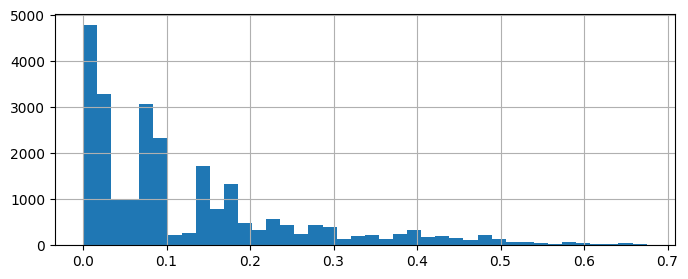

In [14]:
score_cols = [f"s_{col}" for col, *_ in PARAMS]
weights    = [w for *_, w in PARAMS]

df["weighted_score"] = sum(w * df[c] for c, w in zip(score_cols, weights))
print(df.head().to_string())

print(f"Score range: {df['weighted_score'].min():.3f}  to  {df['weighted_score'].max():.3f}")
df["weighted_score"].hist(bins=40, figsize=(8, 3))


### Step 3 — 3-Layer Label Assignment

In [15]:
def assign_label(row):

    # LAYER 1 — Hard overrides
    # Fish will not feed at these values regardless of all other parameters.
    # No calculation needed — return Halt immediately.
    if row["DO"]            < 3.0:  return 2   # Boyd 1990; Tran-Duy et al. 2008
    if row["PH"]            < 6.0:  return 2   # Pillay 2004; Boyd 1990
    if row["PH"]            > 9.0:  return 2   # Boyd 1990
    if row["AMMONIA(mg/l)"] > 0.25: return 2   # Hargreaves & Tucker 2004
    if row["TEMP"]          < 15.0: return 2   # Pillay 2004 — cessation below 15-16 C
    if row["TEMP"]          > 33.0: return 2   # Das et al. 2012

    # LAYER 2 — Tolerance zone (Sprague 1990 NOEL; Wedemeyer 1996)
    # Trivial noise at a boundary produces no observable stress response.
    if row["weighted_score"] <= 0.05: return 0  # Prime Feed

    # LAYER 3 — Weighted score decides
    if row["weighted_score"] <= 0.35: return 1  # Reduce Feed
    return 2                                     # Halt Feeding


df["feed_label"] = df.apply(assign_label, axis=1)

total = len(df)
for cls, name in {0: "Prime Feed", 1: "Reduce Feed", 2: "Halt Feeding"}.items():
    n = (df["feed_label"] == cls).sum()
    print(f"  Class {cls} ({name}): {n:,}  ({n/total*100:.1f}%)")


  Class 0 (Prime Feed): 9,010  (35.4%)
  Class 1 (Reduce Feed): 6,546  (25.7%)
  Class 2 (Halt Feeding): 9,873  (38.8%)


## 6. Save

In [16]:
keep = ["datetime","DO","PH","AMMONIA(mg/l)","TEMP","NITRATE(PPM)","TURBIDITY","feed_label"]
df[keep].to_csv("../data/processed/station2_labelled.csv", index=False)
print(f"Saved: station2_labelled.csv  ({len(df):,} rows)")
df[keep].head()


Saved: station2_labelled.csv  (25,429 rows)


,datetime,DO,PH,AMMONIA(mg/l),TEMP,NITRATE(PPM),TURBIDITY,feed_label
0,2022-02-01 00:00:00,8.21866,5.656,0.022088,22.91168,29.172,29.9592,2
1,2022-02-01 00:20:00,6.23826,5.858,0.071284,22.77000,14.280,32.8320,2
2,2022-02-01 00:40:00,6.33728,5.454,0.058232,22.73964,5.712,25.6500,2
3,2022-02-01 01:00:00,10.00102,5.353,0.018072,22.33484,21.114,21.1356,2
4,2022-02-01 01:20:00,11.09024,5.050,0.060240,22.14256,7.446,24.2136,2
